In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
df=pd.read_csv("SalaryData.csv")

In [3]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [16]:
le = LabelEncoder() # conver string to float for our model 

df["Education Level"] = le.fit_transform(df["Education Level"])
df["Gender"] = le.fit_transform(df["Gender"])
df["Job Title"] = le.fit_transform(df["Job Title"])
df = df.dropna()

In [17]:
X=df[["Job Title","Education Level","Gender","Age","Years of Experience"]]
y=df.Salary

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [19]:
scaler=StandardScaler()

In [20]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [21]:
reg=LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
mse=cross_val_score(reg,X_train,y_train,scoring="neg_mean_squared_error",cv=10)

In [25]:
mse

array([-2.84069155e+08, -1.37972073e+08, -1.73011493e+08, -1.63197038e+08,
       -2.75424612e+08, -2.64431322e+08, -2.28225314e+08, -4.52712493e+08,
       -2.33413054e+08, -2.15630258e+08])

In [26]:
np.mean(mse)

np.float64(-242808681.19021955)

In [28]:
predict_reg=reg.predict(X_test)

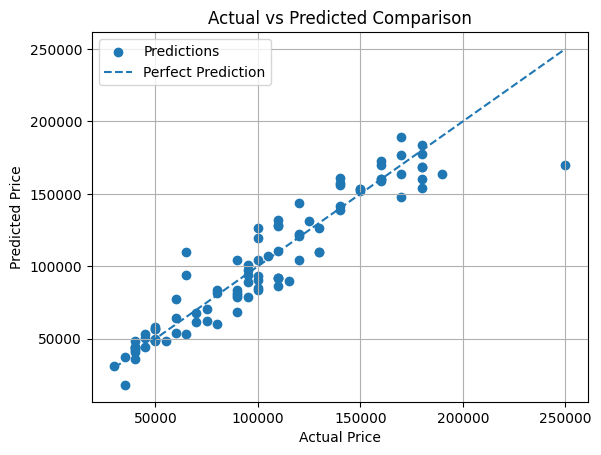

In [32]:
plt.scatter(y_test, predict_reg, label="Predictions")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--",
         label="Perfect Prediction")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Comparison")

plt.legend()
plt.grid()

plt.show()

In [33]:
r2=r2_score(y_test,predict_reg)

In [35]:
r2

0.8854685428774243